## Objectives
1. Load all 4 finetuned BERT models
2. Evaluate model performance on test data
3. Compare model performances

In [2]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from datasets import Dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from peft import PeftModel, PeftConfig

Load the data

In [3]:
test_df = pd.read_csv("test.csv")
print(test_df.shape)

# Convert string labels to binary labels
label_to_id_map = {"negative": 0, "positive": 1}
id_to_label_map = {0: "negative", 1: "positive"}
test_df["label"] = test_df["label"].map(label_to_id_map)
print(test_df.head())

(7484, 2)
   label                                             review
0      0  Howlingly Horrible: This was one of the most e...
1      1  Shocking for its time: This movie about a bunc...
2      1  Bowie keeps on getting better and better: Davi...
3      1  Meryl Streep is Great: Great movie for it's ti...
4      0  Not what I expected: I purchased this for my g...


Define metrics

In [4]:
def compute_metrics(pred):
  labels = pred.label_ids
  preds = pred.predictions.argmax(-1)
  f1 = f1_score(labels, preds, average='weighted')
  acc = accuracy_score(labels, preds)
  precision = precision_score(labels, preds, average='weighted')
  recall = recall_score(labels, preds, average='weighted')
  return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}

Retrieve the finetuned models from huggingface platform and evaluate performance on test data

In [25]:
model_names_to_evaluate = {
    "Original pretrained BERT model":"cxl1020/bert-for-Amazon-sentiment-analysis",
    "Full finetuned BERT model":"cxl1020/full-finetuned-bert-for-Amazon-sentiment-analysis",
    "LORA finetuned BERT model":"cxl1020/LORA-finetuned-bert-for-Amazon-sentiment-analysis",
    "Prompt finetuned BERT model":"cxl1020/prompt-finetuned-bert-for-Amazon-sentiment-analysis"
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [26]:
all_model_evaluation_results = {}

for peft_bert_model, current_model_name in model_names_to_evaluate.items():
    print(f"\nEvaluating {peft_bert_model}...................................")

    # Special handling for prompt-finetuned model
    if "prompt-finetuned" in current_model_name:
        peft_config = PeftConfig.from_pretrained(current_model_name)
        base_model = AutoModelForSequenceClassification.from_pretrained(
            peft_config.base_model_name_or_path,
            num_labels=2
        )
        # Load the PEFT adapter onto the base model
        model = PeftModel.from_pretrained(base_model, current_model_name)
        tokenizer = AutoTokenizer.from_pretrained(current_model_name)
    else:
        # Load model and tokenizer for other models
        model = AutoModelForSequenceClassification.from_pretrained(current_model_name)
        tokenizer = AutoTokenizer.from_pretrained(current_model_name)

    # Define tokenize function specific to the current tokenizer
    def tokenize_function_current(text):
        if current_model_name == "cxl1020/prompt-finetuned-bert-for-Amazon-sentiment-analysis":
            max_seq_length = tokenizer.model_max_length - 20   # to account for the 20 prepended tokens to input
            return tokenizer(text["review"], padding="max_length", truncation=True, max_length=max_seq_length)
        return tokenizer(text["review"], padding="max_length", truncation=True)

    # Convert test_df to Dataset and tokenize
    test_dataset_for_current_model = Dataset.from_pandas(test_df.copy())
    tokenized_test_df_current = test_dataset_for_current_model.map(tokenize_function_current, batched=True)

    eval_args = TrainingArguments(
        output_dir=f'./eval_results/{current_model_name.replace("/", "-")}',
        do_train=False,  # don't train the model
        do_eval=True,  # evaluate the model
        per_device_eval_batch_size=32,
        report_to='none',
        disable_tqdm=True
    )

    trainer = Trainer(
        model=model,
        args=eval_args,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
        eval_dataset=tokenized_test_df_current
    )

    # Get predictions and evaluation metrics
    preds_outputs = trainer.predict(tokenized_test_df_current)
    evaluation_metrics = preds_outputs.metrics

    # Get predicted labels
    y_preds = np.argmax(preds_outputs.predictions, axis=1)
    y_true = preds_outputs.label_ids

    # Get classification report
    class_report = classification_report(y_true, y_preds, target_names=id_to_label_map.values())

    # Build confusion matrix
    cm = confusion_matrix(y_true, y_preds)

    # Store results
    all_model_evaluation_results[peft_bert_model] = {
        "predictions": y_preds,
        "true_labels": y_true,
        "metrics": evaluation_metrics,
        "classification_report": class_report,
        "confusion_matrix": cm,
        "model":model,
        "tokenizer":tokenizer
    }


Evaluating Original pretrained BERT model...................................


Map:   0%|          | 0/7484 [00:00<?, ? examples/s]

/tmp/ipython-input-1068717253.py:41: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(



Evaluating Full finetuned BERT model...................................


Map:   0%|          | 0/7484 [00:00<?, ? examples/s]

...

/tmp/ipython-input-1068717253.py:41: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(



Evaluating Prompt finetuned BERT model...................................


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/7484 [00:00<?, ? examples/s]

/tmp/ipython-input-1068717253.py:41: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Print out the performance of each model


--- All Model Evaluation Results ---

Model: Original pretrained BERT model
Metrics: {'test_loss': 0.7126112580299377, 'test_model_preparation_time': 0.0027, 'test_accuracy': 0.5069481560662747, 'test_f1': 0.3706194162939088, 'test_precision': 0.48648525123402997, 'test_recall': 0.5069481560662747, 'test_runtime': 228.4683, 'test_samples_per_second': 32.757, 'test_steps_per_second': 1.024}
Classification Report:
              precision    recall  f1-score   support

    negative       0.46      0.03      0.06      3670
    positive       0.51      0.96      0.67      3814

    accuracy                           0.51      7484
   macro avg       0.49      0.50      0.36      7484
weighted avg       0.49      0.51      0.37      7484



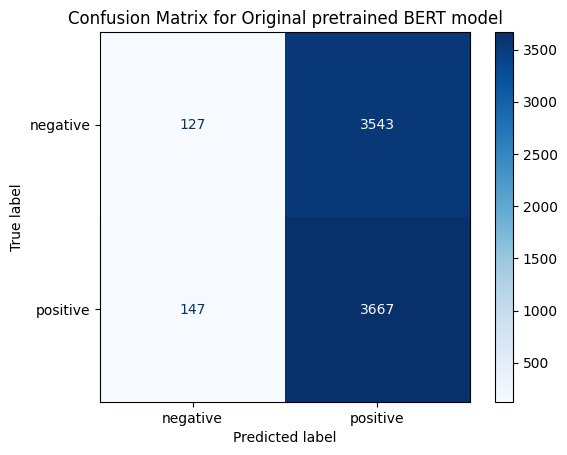


Model: Full finetuned BERT model
Metrics: {'test_loss': 0.37386178970336914, 'test_model_preparation_time': 0.003, 'test_accuracy': 0.9498931052912881, 'test_f1': 0.9498882494196265, 'test_precision': 0.9499160119319394, 'test_recall': 0.9498931052912881, 'test_runtime': 229.1082, 'test_samples_per_second': 32.666, 'test_steps_per_second': 1.021}
Classification Report:
              precision    recall  f1-score   support

    negative       0.95      0.94      0.95      3670
    positive       0.95      0.95      0.95      3814

    accuracy                           0.95      7484
   macro avg       0.95      0.95      0.95      7484
weighted avg       0.95      0.95      0.95      7484



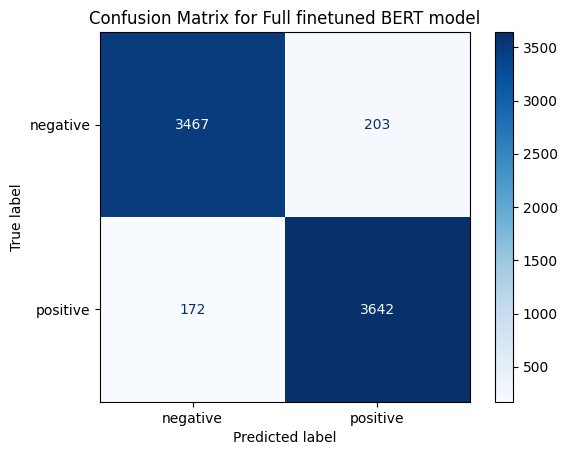


Model: LORA finetuned BERT model
Metrics: {'test_loss': 0.22620853781700134, 'test_model_preparation_time': 0.0048, 'test_accuracy': 0.9172902191341529, 'test_f1': 0.9172428096301527, 'test_precision': 0.9176761021942513, 'test_recall': 0.9172902191341529, 'test_runtime': 239.1833, 'test_samples_per_second': 31.29, 'test_steps_per_second': 0.978}
Classification Report:
              precision    recall  f1-score   support

    negative       0.93      0.90      0.91      3670
    positive       0.91      0.93      0.92      3814

    accuracy                           0.92      7484
   macro avg       0.92      0.92      0.92      7484
weighted avg       0.92      0.92      0.92      7484



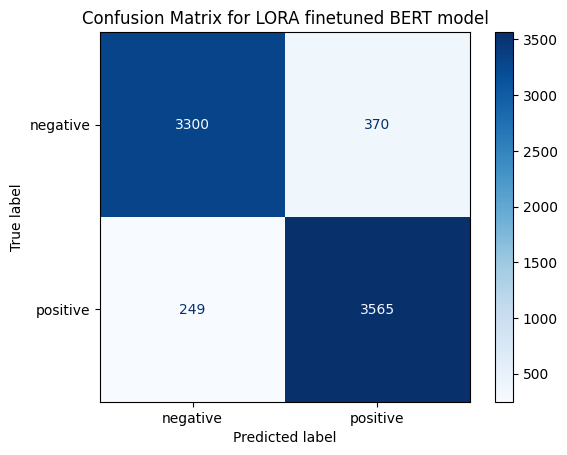


Model: Prompt finetuned BERT model
Metrics: {'test_loss': 0.6861083507537842, 'test_model_preparation_time': 0.0026, 'test_accuracy': 0.5704168893639765, 'test_f1': 0.5318561040511357, 'test_precision': 0.5957050955953987, 'test_recall': 0.5704168893639765, 'test_runtime': 228.9909, 'test_samples_per_second': 32.683, 'test_steps_per_second': 1.022}
Classification Report:
              precision    recall  f1-score   support

    negative       0.64      0.28      0.39      3670
    positive       0.55      0.85      0.67      3814

    accuracy                           0.57      7484
   macro avg       0.60      0.56      0.53      7484
weighted avg       0.60      0.57      0.53      7484



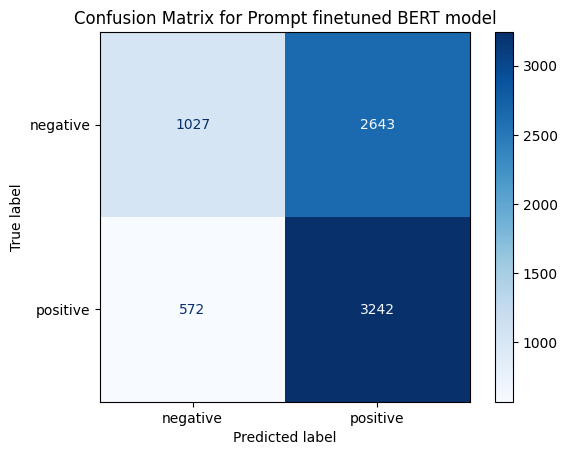

In [27]:
print("\n--- All Model Evaluation Results ---")
for model_name, results in all_model_evaluation_results.items():
    print(f"\nModel: {model_name}")
    print(f"Metrics: {results['metrics']}")
    print(f"Classification Report:\n{results['classification_report']}")
    cm = results['confusion_matrix']
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=id_to_label_map.values())
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix for {model_name}')
    plt.show()

Error analysis

In [28]:
# Identify misclassified examples
for model_name, results in all_model_evaluation_results.items():
    y_preds = results["predictions"]
    y_true = results["true_labels"]
    misclassified_indices = [i for i, (true, pred) in enumerate(zip(y_true, y_preds)) if true != pred]
    misclassified_reviews = [test_df["review"][i] for i in misclassified_indices]
    misclassified_true_labels = [id_to_label_map[y_true[i]] for i in misclassified_indices]
    misclassified_predicted_labels = [id_to_label_map[y_preds[i]] for i in misclassified_indices]

    # Display a few misclassified examples
    print("." *100)
    print(f"| Model: {model_name}")
    print(f"| Number of misclassified examples: {len(misclassified_indices)}")
    print("|\n| Sample misclassified examples:")
    for i in range(min(3, len(misclassified_indices))):
        print(f"| Review: {misclassified_reviews[i]}")
        print(f"| True label: {misclassified_true_labels[i]}")
        print(f"| Predicted label: {misclassified_predicted_labels[i]}")
        print("|", "-" * 50)
    print("." *100)
    print("\n")

....................................................................................................
| Model: Original pretrained BERT model
| Number of misclassified examples: 3690
|
| Sample misclassified examples:
| Review: Howlingly Horrible: This was one of the most embarassingly bad films I've seen in recent memory.I watched this because there is a 14 year old in the house who is understandably amused by girls in their early twenties dancing on top of a bar....and is willing to watch a non-plot for a half-hour between those scenes. Short of a pubescent male, I have to think that anyone who enjoyed this movie is either miguided (hopefully) or an idiot.If this is really what a person looks for in a film, let me recommend saving your money and watching nearly any television sit-com....they're just as bad and it won't cost you four bucks a pop. Take that extra four bucks and donate it to the library. That way, people who are dragging the human race intellectually down to such a depth

Adversarial testing

In [36]:
# Test with adversarial examples, such as oxymorons, spelling errors, conflicting sentiments, sarcasm
adversarial_inputs = ["This movie was surprisingly not bad!",         # true label: positive
                      "This book is ecellent",                        # true label: positive
                      "This is good, but it is too expensive.",       # true label: negative
                      "The service was great... (not really)"]        # true label: negative
for model_name, results in all_model_evaluation_results.items():
    print(f"| Model: {model_name}")
    print("|")
    for text in adversarial_inputs:
        model = results["model"]
        tokenizer = results["tokenizer"]
        tokenized_inputs = tokenizer(text, padding=True, truncation=True, return_tensors="pt")
        tokenized_inputs = {name: tensor.to(device) for name, tensor in tokenized_inputs.items()}

        outputs = model(**tokenized_inputs)
        predictions = torch.argmax(outputs.logits, axis=1)
        print(f"| Adversarial prediction for '{text}': {id_to_label_map[predictions.item()]}")
    print("."*50)

| Model: Original pretrained BERT model
|
| Adversarial prediction for 'This movie was surprisingly not bad!': positive
| Adversarial prediction for 'This book is ecellent': positive
| Adversarial prediction for 'This is good, but it is too expensive.': positive
| Adversarial prediction for 'The service was great... (not really)': positive
..................................................
| Model: Full finetuned BERT model
|
| Adversarial prediction for 'This movie was surprisingly not bad!': positive
| Adversarial prediction for 'This book is ecellent': positive
| Adversarial prediction for 'This is good, but it is too expensive.': negative
| Adversarial prediction for 'The service was great... (not really)': positive
..................................................
| Model: LORA finetuned BERT model
|
| Adversarial prediction for 'This movie was surprisingly not bad!': positive
| Adversarial prediction for 'This book is ecellent': positive
| Adversarial prediction for 'This is goo